# Notebook 00: Data Preparation & Exploratory Data Analysis

## Goal
Replace the hand-curated prompt dataset (120 synthetic prompts) with **real human-generated prompts** from two HuggingFace datasets, grounding our mechanistic interpretability experiments in authentic user behavior.

## Datasets

| Dataset | Size | Key Column | Source |
|---------|------|------------|--------|
| **Search Arena 24k** | 24,069 conversations | `primary_intent` (9 categories) | [lmarena-ai/search-arena-24k](https://huggingface.co/datasets/lmarena-ai/search-arena-24k) |
| **WildChat 4.8M** | 2.75M messages | `topic` (multiple categories) | [how2everything/WildChat-4.8M](https://huggingface.co/datasets/how2everything/WildChat-4.8M) |

## Category Mapping

| Our Category | Search Arena Intents | WildChat Topics |
|-------------|---------------------|-----------------|
| **math** | Analysis/Explanation (keyword-filtered) | tutoring_or_teaching (keyword-filtered) |
| **code** | â€” | computer_programming |
| **factual** | Factual Lookup, Information Synthesis | health_fitness_beauty_or_self_care |
| **creative** | Creative Generation | creative_ideation |
| **emotional** | â€” | greetings_and_chitchat (keyword-filtered) |
| **reasoning** | Analysis, Explanation | tutoring_or_teaching |

## Output
- `data/prompts.json` â€” 50 prompts per category (300 total), pipeline-compatible
- `data/prompts_metadata.json` â€” source provenance per prompt
- `results/figures/eda/` â€” all EDA visualizations

In [1]:
# â”€â”€â”€ Cell 1: Imports & Configuration â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
import json
import random
import re
import os
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from tqdm import tqdm

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Target: 50 prompts per category (300 total)
TARGET_PER_CATEGORY = 50
CATEGORIES = ['math', 'code', 'factual', 'creative', 'emotional', 'reasoning']

# Paths
DATA_DIR = Path('data')
DATA_DIR.mkdir(exist_ok=True)
FIGURES_DIR = Path('results/figures/eda')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Style
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

print(f'Target: {TARGET_PER_CATEGORY} prompts x {len(CATEGORIES)} categories = {TARGET_PER_CATEGORY * len(CATEGORIES)} total')
print(f'Categories: {CATEGORIES}')
print('Imports loaded.')

Target: 50 prompts x 6 categories = 300 total
Categories: ['math', 'code', 'factual', 'creative', 'emotional', 'reasoning']
Imports loaded.


In [2]:
# â”€â”€â”€ Cell 2: Load Search Arena 24k â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# ~400MB parquet, 24k conversations with intent labels (Cohen's kappa = 0.812)
# Only has a "test" split

print('Loading Search Arena 24k...')
sa_ds = load_dataset("lmarena-ai/search-arena-24k", split="test")
print(f'Loaded {len(sa_ds)} rows')
print(f'Columns: {sa_ds.column_names}')

# Extract the first user message from messages_a
def extract_user_prompt_sa(row):
    """Extract first user message from messages_a conversation."""
    messages = row.get('messages_a', [])
    if messages is None:
        return None
    for msg in messages:
        if isinstance(msg, dict) and msg.get('role') == 'user':
            content = msg.get('content', '')
            if isinstance(content, str) and len(content.strip()) > 0:
                return content.strip()
    return None

sa_df = sa_ds.to_pandas()
sa_df['user_prompt'] = sa_df.apply(extract_user_prompt_sa, axis=1)
sa_df = sa_df.dropna(subset=['user_prompt'])

print(f'\nExtracted {len(sa_df)} user prompts')
print(f'\nprimary_intent value counts:')
print(sa_df['primary_intent'].value_counts().to_string())

Loading Search Arena 24k...
Loaded 24069 rows
Columns: ['model_a', 'model_b', 'winner', 'judge', 'turn', 'timestamp', 'messages_a', 'messages_b', 'system_a_metadata', 'system_b_metadata', 'primary_intent', 'secondary_intent', 'languages']

Extracted 24069 user prompts

primary_intent value counts:
primary_intent
Factual Lookup         4655
Info Synthesis         4477
Analysis               2633
Recommendation         2590
Explanation            2505
Creative Generation    2287
Guidance               2195
Other                  1974
Text Processing         752


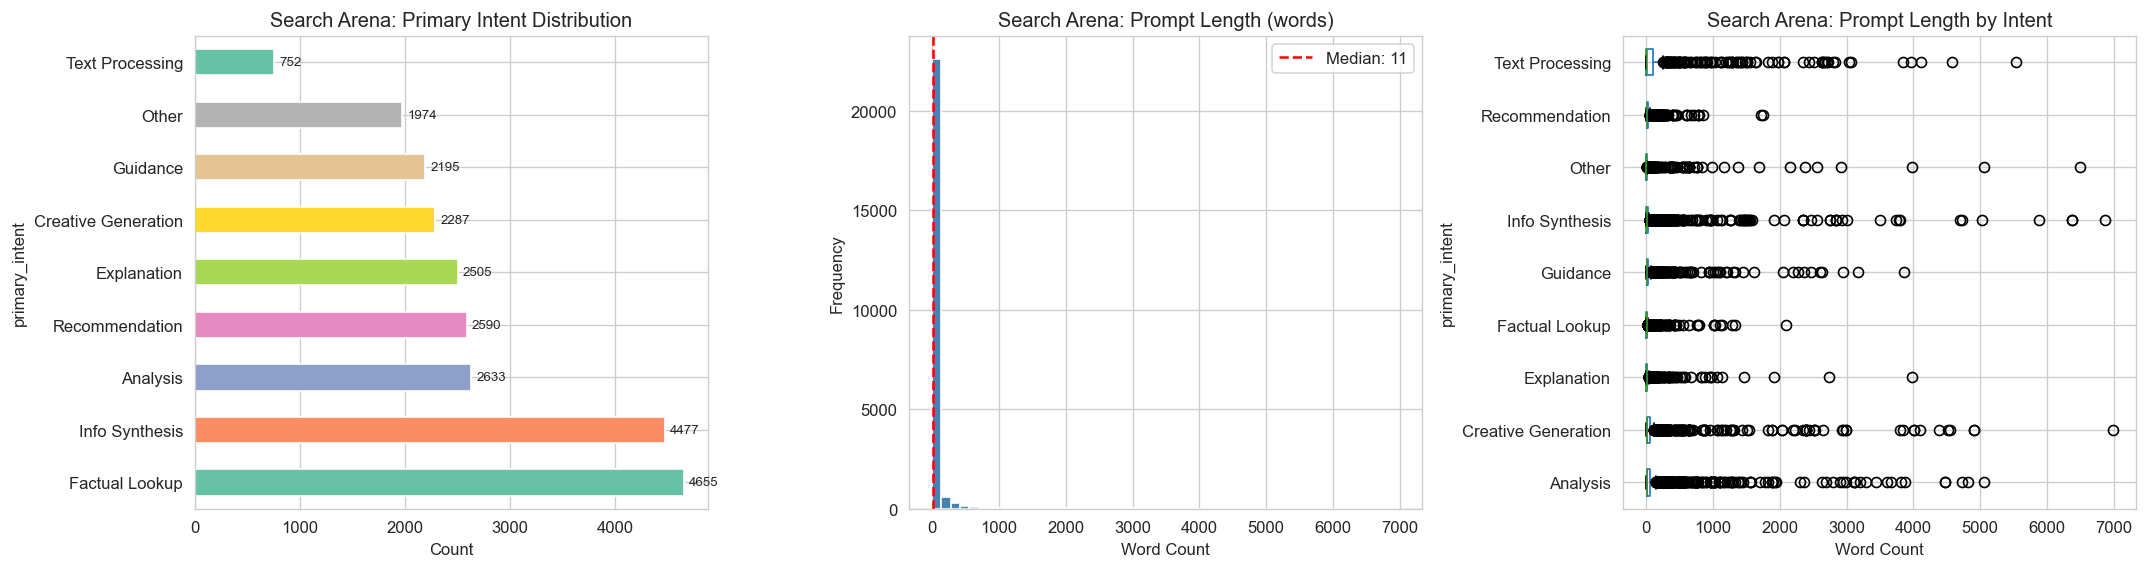

Figure saved: eda_search_arena_overview.png


In [3]:
# â”€â”€â”€ Cell 3: EDA â€” Search Arena Intent Distribution â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 3a. Intent distribution bar chart
intent_counts = sa_df['primary_intent'].value_counts()
colors = sns.color_palette('Set2', len(intent_counts))
intent_counts.plot(kind='barh', ax=axes[0], color=colors)
axes[0].set_title('Search Arena: Primary Intent Distribution')
axes[0].set_xlabel('Count')
for i, (v, name) in enumerate(zip(intent_counts.values, intent_counts.index)):
    axes[0].text(v + 50, i, f'{v}', va='center', fontsize=8)

# 3b. Prompt length histogram (word count)
sa_df['word_count'] = sa_df['user_prompt'].str.split().str.len()
sa_df['word_count'].hist(bins=50, ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Search Arena: Prompt Length (words)')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].axvline(sa_df['word_count'].median(), color='red', linestyle='--', label=f'Median: {sa_df["word_count"].median():.0f}')
axes[1].legend()

# 3c. Length by intent (box plot)
sa_df.boxplot(column='word_count', by='primary_intent', ax=axes[2], vert=False)
axes[2].set_title('Search Arena: Prompt Length by Intent')
axes[2].set_xlabel('Word Count')
plt.suptitle('')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda_search_arena_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: eda_search_arena_overview.png')

In [8]:
# ─── Cell 4: Load WildChat via Streaming ─────────────────────────────────────
# WildChat is ~27GB — we stream it and collect only what we need.
# Target: 500 samples per relevant topic (oversample, filter later)
#
# SCHEMA NOTE: WildChat stores messages in a 'conversation' column (list of dicts),
# NOT as flat role/content columns. Each row is one conversation, with a 'topic' label.

WILDCHAT_TOPICS = {
    'computer_programming',
    'creative_ideation',
    'tutoring_or_teaching',
    'health_fitness_beauty_or_self_care',
    'greetings_and_chitchat',
}
MAX_PER_TOPIC = 500

print('Streaming WildChat-4.8M (this may take a few minutes)...')
print(f'Collecting up to {MAX_PER_TOPIC} samples per topic for: {WILDCHAT_TOPICS}')

wc_stream = load_dataset(
    "how2everything/WildChat-4.8M",
    split="train",
    streaming=True
)

# Inspect schema from first row
first_row = next(iter(wc_stream))
print(f'WildChat columns: {list(first_row.keys())}')

# Show conversation structure
conv = first_row.get('conversation', [])
print(f'Conversation type: {type(conv)}, length: {len(conv) if isinstance(conv, list) else "N/A"}')
if isinstance(conv, list) and len(conv) > 0:
    print(f'First message keys: {list(conv[0].keys()) if isinstance(conv[0], dict) else type(conv[0])}')
    print(f'First message preview: role={conv[0].get("role","?")}, content={str(conv[0].get("content",""))[:100]}...')

wildchat_samples = []
topic_counts = Counter()
rows_scanned = 0

for row in tqdm(wc_stream, desc="Scanning WildChat"):
    rows_scanned += 1

    # Check if all topics are full
    if all(topic_counts.get(t, 0) >= MAX_PER_TOPIC for t in WILDCHAT_TOPICS):
        break

    # Safety: stop after 2M rows max
    if rows_scanned > 2_000_000:
        print(f'Reached {rows_scanned} row scan limit')
        break

    topic = row.get('topic', '')
    if isinstance(topic, list):
        topic = topic[0] if topic else ''

    if topic not in WILDCHAT_TOPICS:
        continue
    if topic_counts[topic] >= MAX_PER_TOPIC:
        continue

    # Language filter (English)
    lang = str(row.get('language', ''))
    if lang and 'en' not in lang.lower()[:5]:
        continue

    # Extract first user message from conversation list
    conversation = row.get('conversation', [])
    if not isinstance(conversation, list):
        continue

    user_content = None
    for msg in conversation:
        if isinstance(msg, dict) and msg.get('role') == 'user':
            content = msg.get('content', '')
            if isinstance(content, str) and len(content.strip()) >= 10:
                user_content = content.strip()
                break

    if user_content is None:
        continue

    wildchat_samples.append({
        'content': user_content,
        'topic': topic,
        'source': 'wildchat'
    })
    topic_counts[topic] += 1

wc_df = pd.DataFrame(wildchat_samples)
print(f'Scanned {rows_scanned:,} rows')
print(f'Collected {len(wc_df)} samples')
print(f'Topic counts:')
for topic, count in topic_counts.most_common():
    print(f'  {topic}: {count}')

Streaming WildChat-4.8M (this may take a few minutes)...


Resolving data files:   0%|          | 0/69 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/69 [00:00<?, ?it/s]

WildChat columns: ['conversation_hash', 'model', 'timestamp', 'conversation', 'turn', 'language', 'openai_moderation', 'detoxify_moderation', 'toxic', 'redacted', 'state', 'country', 'hashed_ip', 'header', 'topic']
Conversation type: <class 'list'>, length: 4
First message keys: ['content', 'created', 'header', 'hashed_ip', 'country', 'toxic', 'redacted', 'state', 'language', 'openai_id', 'role', 'temperature', 'timestamp', 'token_counter', 'top_p', 'turn_identifier', 'system_fingerprint', 'usage']
First message preview: role=user, content=Crea una imagen de una mujer corriente por la playa en bikini ...


Scanning WildChat: 81891it [04:00, 340.09it/s]

Scanned 81,892 rows
Collected 2500 samples
Topic counts:
  health_fitness_beauty_or_self_care: 500
  tutoring_or_teaching: 500
  greetings_and_chitchat: 500
  computer_programming: 500
  creative_ideation: 500


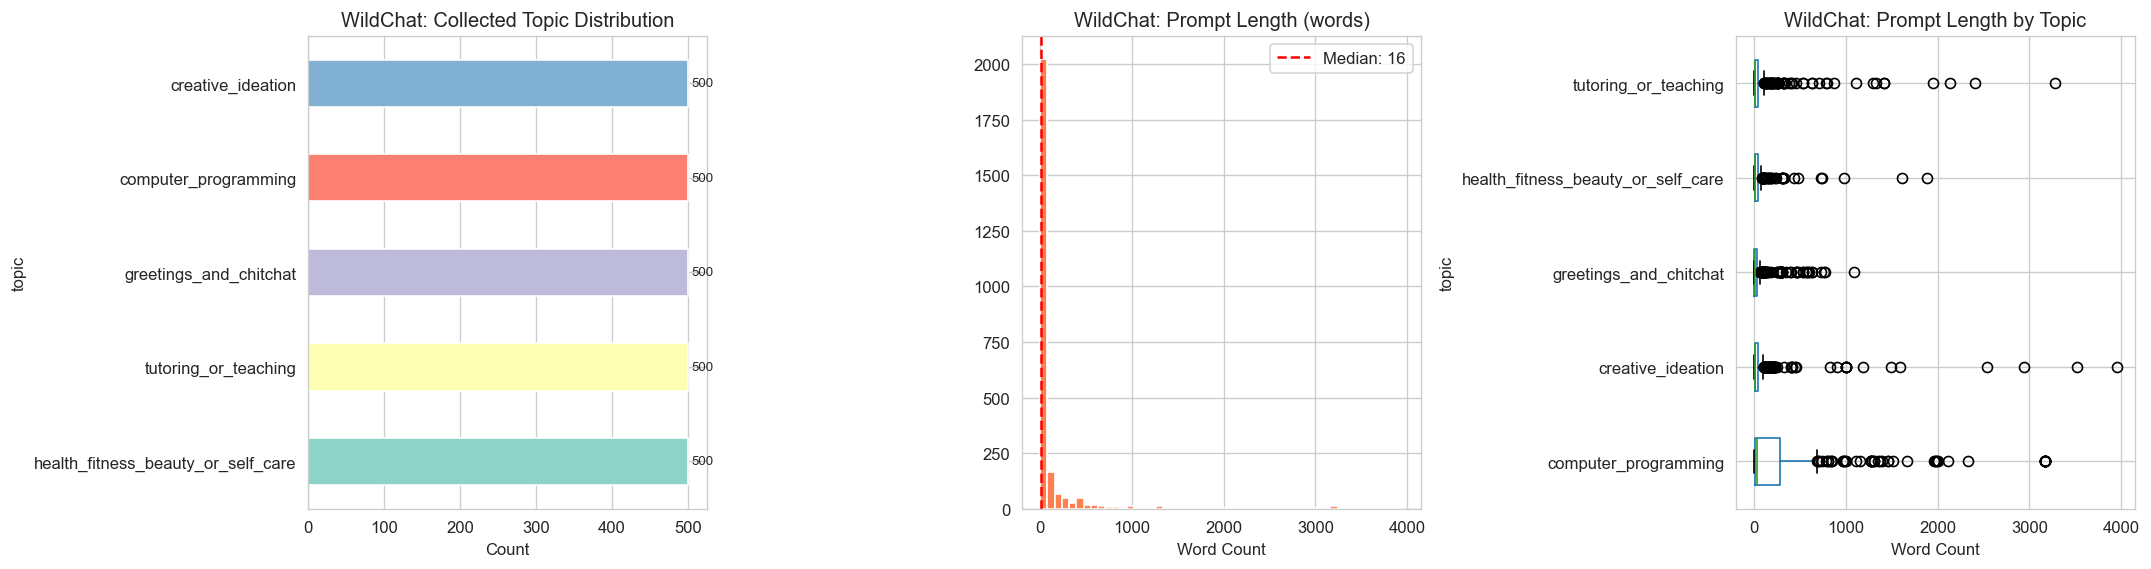


--- Sample Prompts per WildChat Topic ---

[health_fitness_beauty_or_self_care]
  1. Old age PT hx of DM, HTN, dyslipidemia His ECG I.II, aVF (MI) what is the highest risk 

factor for this condition?
  2. What is a meal with good macros from Taco Bell that does not contain beans?
  3. The following is an article that I will ask you questions about, ok?:

 Access to the most commonly used method of abort...

[tutoring_or_teaching]
  1. Dosage colorimétrique des polyphénols pricipe en maximum 85 line
  2. Provide a design for a disk topology for a NAS built on TrueNAS Scale, as well as a dataset layout. The available disks ...
  3. How did Hurricane Florence lose strength?

[greetings_and_chitchat]
  1. how long does it take to orbit the sun?
  2. TrueNAS: Is there any benefit to creating a separate pool for data that is irreplaceable, or is it better to just add an...
  3. I’m going to shift realities tonight.

[computer_programming]
  1. selenium.common.exceptions.UnexpectedAlertPres

In [9]:
# â”€â”€â”€ Cell 5: EDA â€” WildChat Topic Distribution â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 5a. Topic counts
if len(wc_df) > 0:
    wc_topic_counts = wc_df['topic'].value_counts()
    wc_topic_counts.plot(kind='barh', ax=axes[0], color=sns.color_palette('Set3', len(wc_topic_counts)))
    axes[0].set_title('WildChat: Collected Topic Distribution')
    axes[0].set_xlabel('Count')
    for i, v in enumerate(wc_topic_counts.values):
        axes[0].text(v + 5, i, f'{v}', va='center', fontsize=8)

    # 5b. Prompt length histogram
    wc_df['word_count'] = wc_df['content'].str.split().str.len()
    wc_df['word_count'].hist(bins=50, ax=axes[1], color='coral', edgecolor='white')
    axes[1].set_title('WildChat: Prompt Length (words)')
    axes[1].set_xlabel('Word Count')
    axes[1].axvline(wc_df['word_count'].median(), color='red', linestyle='--',
                     label=f'Median: {wc_df["word_count"].median():.0f}')
    axes[1].legend()

    # 5c. Length by topic
    wc_df.boxplot(column='word_count', by='topic', ax=axes[2], vert=False)
    axes[2].set_title('WildChat: Prompt Length by Topic')
    axes[2].set_xlabel('Word Count')
    plt.suptitle('')
else:
    for ax in axes:
        ax.text(0.5, 0.5, 'No WildChat data collected', ha='center', va='center', transform=ax.transAxes)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda_wildchat_overview.png', dpi=150, bbox_inches='tight')
plt.show()

# Show sample prompts per topic
if len(wc_df) > 0:
    print('\n--- Sample Prompts per WildChat Topic ---')
    for topic in wc_df['topic'].unique():
        print(f'\n[{topic}]')
        samples = wc_df[wc_df['topic'] == topic]['content'].head(3)
        for i, s in enumerate(samples):
            print(f'  {i+1}. {s[:120]}...' if len(s) > 120 else f'  {i+1}. {s}')

In [10]:
# â”€â”€â”€ Cell 6: Quality Filtering Functions â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€

def quality_filter(text):
    """Return True if prompt passes all quality checks."""
    if not isinstance(text, str) or len(text.strip()) < 10:
        return False
    words = text.split()
    # Length bounds: 3-200 words
    if len(words) < 3 or len(words) > 200:
        return False
    # Reject extremely repetitive text (type-token ratio < 0.3)
    if len(set(w.lower() for w in words)) / len(words) < 0.3:
        return False
    # Reject garbled / non-language text (alpha ratio < 0.5)
    alpha_count = sum(c.isalpha() or c.isspace() for c in text)
    if alpha_count / len(text) < 0.5:
        return False
    return True

# Math keyword detector
MATH_KEYWORDS = re.compile(
    r'\b(calculate|solve|equation|math|algebra|geometry|integral|derivative|'
    r'probability|percent|sum|multiply|divide|fraction|triangle|circle|radius|'
    r'area|volume|graph|polynomial|matrix|vector|sin|cos|tan|log|sqrt|theorem|'
    r'prime|factorial|permutation|combination|quadratic|linear|exponential|'
    r'arithmetic|calculus|trigonometry|statistics|median|mean|variance|'
    r'numerator|denominator|ratio|proportion|angle|hypotenuse)\b',
    re.IGNORECASE
)

# Also match numeric expressions like "3+5", "7*8", "what is 15 plus 27"
MATH_EXPR = re.compile(
    r'(\d+\s*[\+\-\*\/\^]\s*\d+)|'
    r'(\b\d+\s+(plus|minus|times|divided by|multiplied by)\s+\d+\b)',
    re.IGNORECASE
)

def is_math_prompt(text):
    """Return True if text contains math-related content."""
    return bool(MATH_KEYWORDS.search(text)) or bool(MATH_EXPR.search(text))

# Emotional keyword detector
EMOTIONAL_KEYWORDS = re.compile(
    r'\b(feel|feeling|felt|sad|happy|angry|anxious|depressed|lonely|'
    r'stressed|overwhelmed|grief|grieving|love|loved|hurt|afraid|worried|'
    r'scared|proud|grateful|confused|frustrated|hopeless|excited|nervous|'
    r'heartbroken|missing|loss|struggling|suffering|joy|sorrow|regret|'
    r'ashamed|guilt|guilty|panic|cry|crying|tears|therapy|therapist|'
    r'mental health|self-esteem|confidence|insecure|vulnerable)\b',
    re.IGNORECASE
)

def is_emotional_prompt(text):
    """Return True if text contains emotional content."""
    return bool(EMOTIONAL_KEYWORDS.search(text))

# Test the filters
test_cases = [
    ("What is the derivative of x^2?", "math"),
    ("Write a python function to sort a list", "code"),
    ("I feel so overwhelmed and sad today", "emotional"),
    ("Tell me about the capital of France", "factual"),
]
for text, expected in test_cases:
    print(f'  quality={quality_filter(text)}, math={is_math_prompt(text)}, '
          f'emotional={is_emotional_prompt(text)} | "{text[:50]}" (expected: {expected})')

print('\nFilters defined.')

  quality=True, math=True, emotional=False | "What is the derivative of x^2?" (expected: math)
  quality=True, math=False, emotional=False | "Write a python function to sort a list" (expected: code)
  quality=True, math=False, emotional=True | "I feel so overwhelmed and sad today" (expected: emotional)
  quality=True, math=False, emotional=False | "Tell me about the capital of France" (expected: factual)

Filters defined.


In [11]:
# ─── Cell 7: Category Mapping — Search Arena ─────────────────────────────────

# Direct intent-to-category mapping
# NOTE: The dataset uses "Info Synthesis" (not "Information Synthesis")
SA_MAPPING = {
    'Factual Lookup': 'factual',
    'Info Synthesis': 'factual',
    'Analysis': 'reasoning',
    'Explanation': 'reasoning',
    'Creative Generation': 'creative',
    'Guidance': None,
    'Recommendation': None,
    'Text Processing': None,
    'Other': None,
}

# Math override intents: prompts in these intents that match math keywords -> math
MATH_OVERRIDE_INTENTS = {'Analysis', 'Explanation', 'Factual Lookup', 'Info Synthesis'}

# Code keyword detector (fallback if WildChat doesn't provide enough)
CODE_KEYWORDS = re.compile(
    r'(python|javascript|java|code|function|class|api|html|css|sql|'
    r'programming|algorithm|debug|compile|syntax|variable|array|loop|'
    r'database|git|docker|react|node|import|library|framework|bug|'
    r'exception|error handling|recursion|sorting|binary|regex|http|json|'
    r'script|terminal|command line|bash|shell|server|deploy)',
    re.IGNORECASE
)

def is_code_prompt(text):
    """Return True if text is about programming/code."""
    return bool(CODE_KEYWORDS.search(text))

sa_pool = {cat: [] for cat in CATEGORIES}
sa_meta = {cat: [] for cat in CATEGORIES}

for _, row in sa_df.iterrows():
    text = row['user_prompt']
    intent = row['primary_intent']

    if not quality_filter(text):
        continue

    # Math sub-classification (highest priority)
    if intent in MATH_OVERRIDE_INTENTS and is_math_prompt(text):
        sa_pool['math'].append(text)
        sa_meta['math'].append({'source': 'search_arena', 'original_intent': intent})
        continue

    # Code sub-classification: scan all intents for code keywords
    if is_code_prompt(text):
        sa_pool['code'].append(text)
        sa_meta['code'].append({'source': 'search_arena', 'original_intent': intent})
        continue

    # Emotional sub-classification: scan all intents for emotional keywords
    if is_emotional_prompt(text):
        sa_pool['emotional'].append(text)
        sa_meta['emotional'].append({'source': 'search_arena', 'original_intent': intent})
        continue

    # Standard mapping
    mapped = SA_MAPPING.get(intent)
    if mapped:
        sa_pool[mapped].append(text)
        sa_meta[mapped].append({'source': 'search_arena', 'original_intent': intent})

print('Search Arena prompt pool per category:')
for cat in CATEGORIES:
    print(f'  {cat}: {len(sa_pool[cat])}')

Search Arena prompt pool per category:
  math: 593
  code: 0
  factual: 7504
  creative: 1950
  emotional: 252
  reasoning: 4014


In [12]:
# â”€â”€â”€ Cell 8: Category Mapping â€” WildChat â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€

WC_MAPPING = {
    'computer_programming': 'code',
    'creative_ideation': 'creative',
    'health_fitness_beauty_or_self_care': 'factual',
    # tutoring_or_teaching and greetings_and_chitchat need sub-classification
}

wc_pool = {cat: [] for cat in CATEGORIES}
wc_meta = {cat: [] for cat in CATEGORIES}

if len(wc_df) > 0:
    for _, row in wc_df.iterrows():
        text = row['content']
        topic = row['topic']

        if not quality_filter(text):
            continue

        # Special handling: tutoring_or_teaching â†’ math or reasoning
        if topic == 'tutoring_or_teaching':
            if is_math_prompt(text):
                wc_pool['math'].append(text)
                wc_meta['math'].append({'source': 'wildchat', 'original_topic': topic, 'sub': 'math_keyword'})
            else:
                wc_pool['reasoning'].append(text)
                wc_meta['reasoning'].append({'source': 'wildchat', 'original_topic': topic})
            continue

        # Special handling: greetings_and_chitchat â†’ emotional (with keyword filter)
        if topic == 'greetings_and_chitchat':
            if is_emotional_prompt(text):
                wc_pool['emotional'].append(text)
                wc_meta['emotional'].append({'source': 'wildchat', 'original_topic': topic, 'sub': 'emotional_keyword'})
            continue

        # Standard mapping
        mapped = WC_MAPPING.get(topic)
        if mapped:
            wc_pool[mapped].append(text)
            wc_meta[mapped].append({'source': 'wildchat', 'original_topic': topic})

print('WildChat prompt pool per category:')
for cat in CATEGORIES:
    print(f'  {cat}: {len(wc_pool[cat])}')

WildChat prompt pool per category:
  math: 66
  code: 322
  factual: 484
  creative: 464
  emotional: 14
  reasoning: 386


In [13]:
# â”€â”€â”€ Cell 9: Merge Pools + Deduplicate â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€

pool = {cat: [] for cat in CATEGORIES}
meta = {cat: [] for cat in CATEGORIES}

# Merge Search Arena and WildChat pools
for cat in CATEGORIES:
    pool[cat].extend(sa_pool[cat])
    meta[cat].extend(sa_meta[cat])
    pool[cat].extend(wc_pool[cat])
    meta[cat].extend(wc_meta[cat])

# Deduplicate within each category (exact match on lowered, stripped text)
for cat in CATEGORIES:
    seen = set()
    unique_prompts = []
    unique_meta = []
    for p, m in zip(pool[cat], meta[cat]):
        key = p.strip().lower()
        if key not in seen:
            seen.add(key)
            unique_prompts.append(p)
            unique_meta.append(m)
    removed = len(pool[cat]) - len(unique_prompts)
    pool[cat] = unique_prompts
    meta[cat] = unique_meta
    if removed > 0:
        print(f'  {cat}: removed {removed} duplicates')

print('\nCombined pool per category (after dedup):')
for cat in CATEGORIES:
    sa_count = sum(1 for m in meta[cat] if m['source'] == 'search_arena')
    wc_count = sum(1 for m in meta[cat] if m['source'] == 'wildchat')
    print(f'  {cat}: {len(pool[cat])} total  (SA: {sa_count}, WC: {wc_count})')

  math: removed 85 duplicates
  code: removed 13 duplicates
  factual: removed 913 duplicates
  creative: removed 422 duplicates
  emotional: removed 55 duplicates
  reasoning: removed 407 duplicates

Combined pool per category (after dedup):
  math: 574 total  (SA: 513, WC: 61)
  code: 309 total  (SA: 0, WC: 309)
  factual: 7075 total  (SA: 6608, WC: 467)
  creative: 1992 total  (SA: 1558, WC: 434)
  emotional: 211 total  (SA: 197, WC: 14)
  reasoning: 3993 total  (SA: 3618, WC: 375)


C:\Users\mukho\AppData\Local\Temp\ipykernel_27016\3191136064.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=length_df, x='category', y='word_count', ax=axes[1, 0],


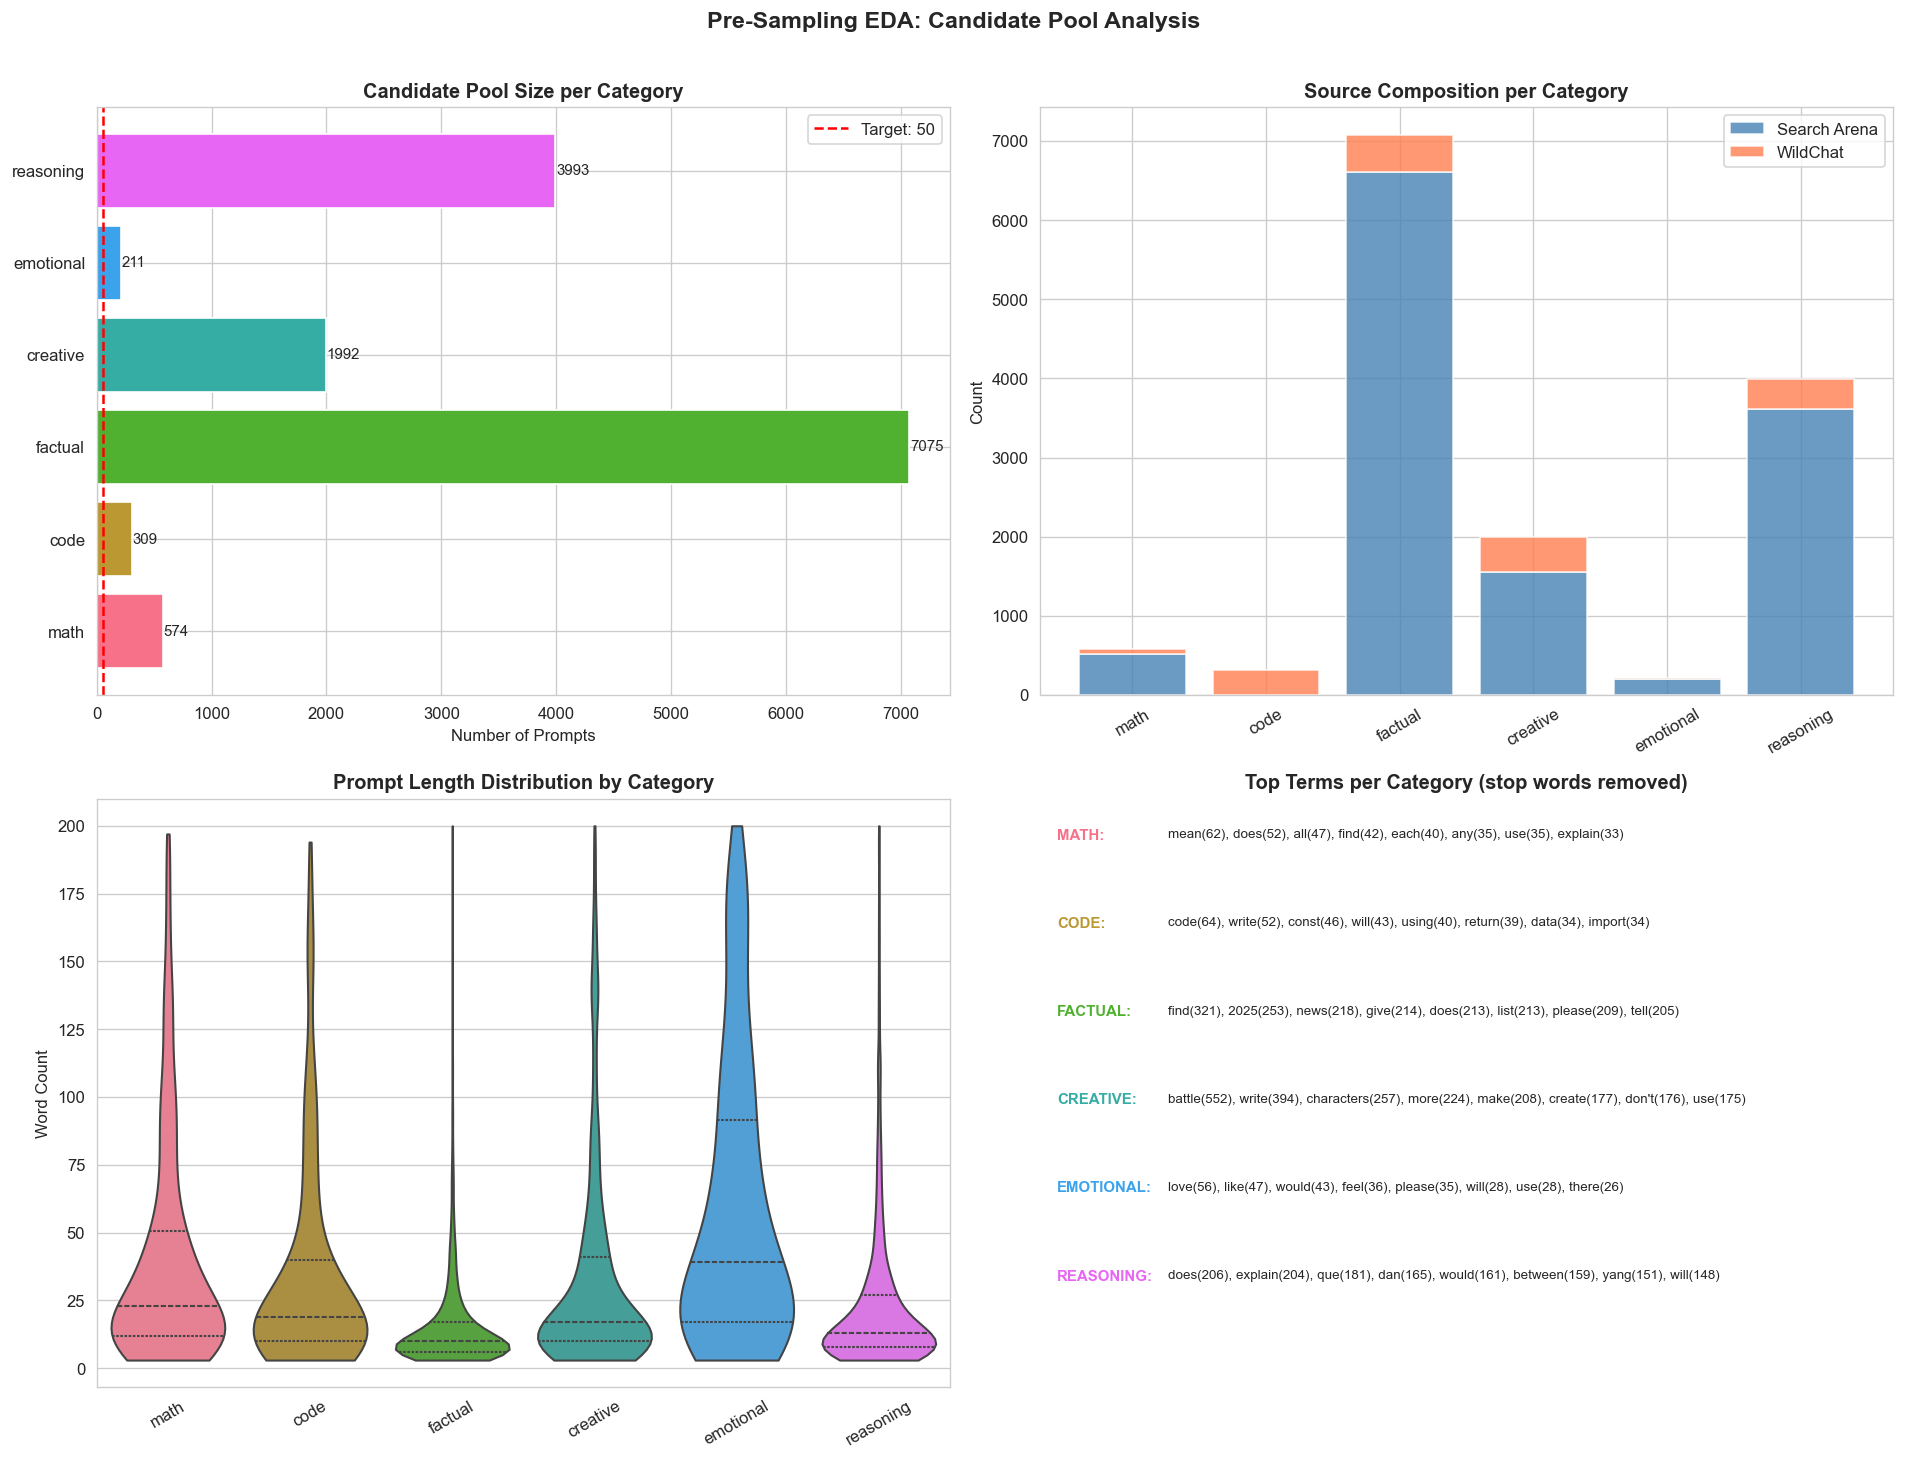

Figure saved: eda_pre_sampling.png


In [14]:
# â”€â”€â”€ Cell 10: EDA â€” Pre-Sampling Analysis â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 10a. Category balance (candidate pool size)
pool_sizes = {cat: len(pool[cat]) for cat in CATEGORIES}
colors_cat = sns.color_palette('husl', len(CATEGORIES))
bars = axes[0, 0].barh(CATEGORIES, [pool_sizes[c] for c in CATEGORIES], color=colors_cat)
axes[0, 0].set_title('Candidate Pool Size per Category', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Number of Prompts')
axes[0, 0].axvline(TARGET_PER_CATEGORY, color='red', linestyle='--', label=f'Target: {TARGET_PER_CATEGORY}')
for bar, cat in zip(bars, CATEGORIES):
    axes[0, 0].text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
                     f'{pool_sizes[cat]}', va='center', fontsize=9)
axes[0, 0].legend()

# 10b. Source composition (stacked bar)
sa_counts = [sum(1 for m in meta[c] if m['source'] == 'search_arena') for c in CATEGORIES]
wc_counts = [sum(1 for m in meta[c] if m['source'] == 'wildchat') for c in CATEGORIES]
x = np.arange(len(CATEGORIES))
axes[0, 1].bar(x, sa_counts, label='Search Arena', color='steelblue', alpha=0.8)
axes[0, 1].bar(x, wc_counts, bottom=sa_counts, label='WildChat', color='coral', alpha=0.8)
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(CATEGORIES, rotation=30)
axes[0, 1].set_title('Source Composition per Category', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Count')
axes[0, 1].legend()

# 10c. Prompt length violin plots by category
length_data = []
for cat in CATEGORIES:
    for p in pool[cat]:
        length_data.append({'category': cat, 'word_count': len(p.split())})
length_df = pd.DataFrame(length_data)

if len(length_df) > 0:
    sns.violinplot(data=length_df, x='category', y='word_count', ax=axes[1, 0],
                    palette='husl', cut=0, inner='quartile')
    axes[1, 0].set_title('Prompt Length Distribution by Category', fontsize=12, fontweight='bold')
    axes[1, 0].set_ylabel('Word Count')
    axes[1, 0].set_xlabel('')
    axes[1, 0].tick_params(axis='x', rotation=30)

# 10d. Top-10 terms per category (excluding common stop words)
STOP_WORDS = {'the', 'a', 'an', 'is', 'it', 'of', 'to', 'in', 'and', 'for',
              'on', 'with', 'that', 'this', 'are', 'was', 'be', 'as', 'at',
              'by', 'or', 'from', 'not', 'but', 'can', 'do', 'has', 'have',
              'i', 'you', 'he', 'she', 'we', 'they', 'my', 'your', 'what',
              'how', 'which', 'who', 'when', 'where', 'why', 'if', 'me', 'about'}

cat_top_words = {}
for cat in CATEGORIES:
    all_words = []
    for p in pool[cat]:
        all_words.extend(w.lower().strip('.,!?;:"()[]') for w in p.split()
                        if w.lower().strip('.,!?;:"()[]') not in STOP_WORDS
                        and len(w) > 2)
    top = Counter(all_words).most_common(8)
    cat_top_words[cat] = top

# Display as text-based summary in the plot
axes[1, 1].axis('off')
axes[1, 1].set_title('Top Terms per Category (stop words removed)', fontsize=12, fontweight='bold')
y_pos = 0.95
for cat in CATEGORIES:
    terms = ', '.join(f'{w}({c})' for w, c in cat_top_words[cat])
    axes[1, 1].text(0.02, y_pos, f'{cat.upper()}:', fontsize=9, fontweight='bold',
                     transform=axes[1, 1].transAxes, va='top', color=colors_cat[CATEGORIES.index(cat)])
    axes[1, 1].text(0.15, y_pos, terms, fontsize=8,
                     transform=axes[1, 1].transAxes, va='top')
    y_pos -= 0.15

plt.suptitle('Pre-Sampling EDA: Candidate Pool Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda_pre_sampling.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: eda_pre_sampling.png')

Loading GPT-2 tokenizer...


Token indices sequence length is longer than the specified maximum sequence length for this model (1176 > 1024). Running this sequence through the model will result in indexing errors
C:\Users\mukho\AppData\Local\Temp\ipykernel_27016\2567642706.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=token_df, x='category', y='tokens', ax=axes[1], palette='husl')


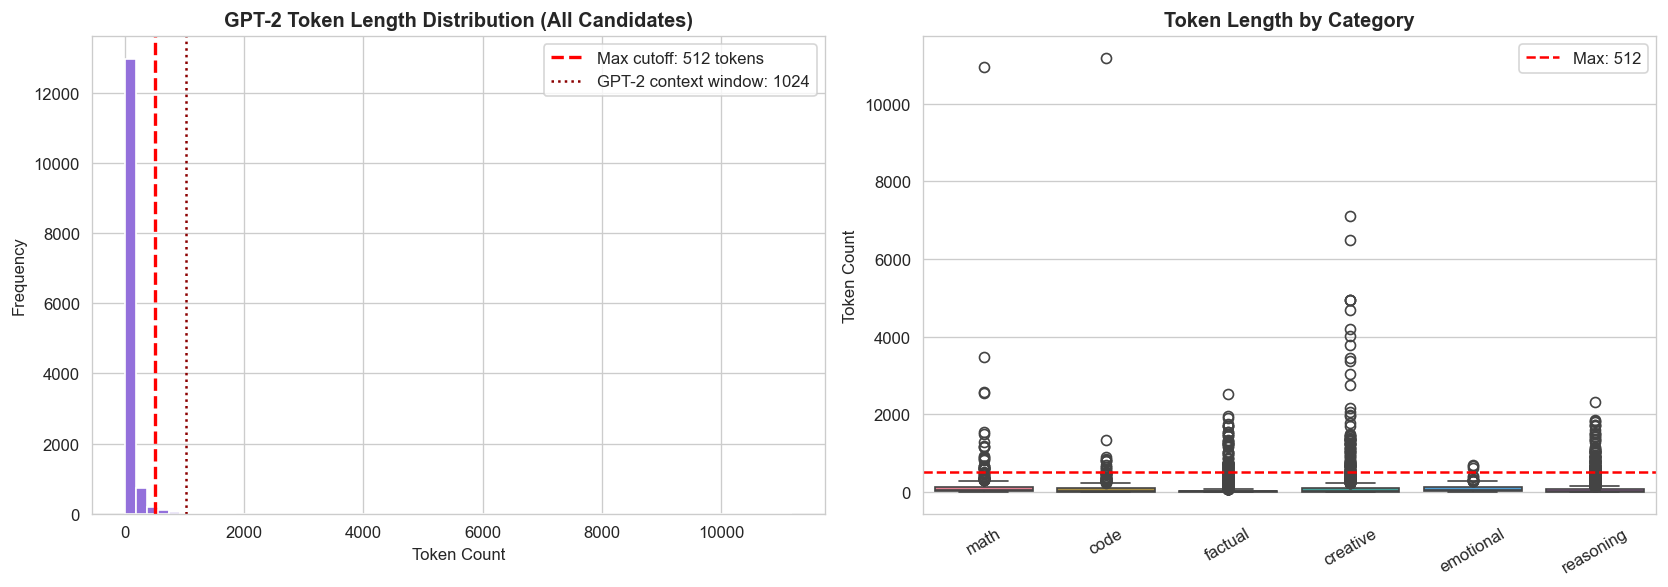

  math: removed 26 prompts exceeding 512 tokens
  code: removed 12 prompts exceeding 512 tokens
  factual: removed 71 prompts exceeding 512 tokens
  creative: removed 89 prompts exceeding 512 tokens
  emotional: removed 3 prompts exceeding 512 tokens
  reasoning: removed 102 prompts exceeding 512 tokens

Pool sizes after token filtering:
  math: 548
  code: 297
  factual: 7004
  creative: 1903
  emotional: 208
  reasoning: 3891


In [15]:
# â”€â”€â”€ Cell 11: GPT-2 Token Length Analysis â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
from transformers import AutoTokenizer

print('Loading GPT-2 tokenizer...')
tokenizer = AutoTokenizer.from_pretrained('gpt2')
MAX_TOKENS = 512  # Leave headroom for GPT-2's 1024 context window

# Tokenize all candidate prompts
token_data = []
filtered_out = {cat: 0 for cat in CATEGORIES}

for cat in CATEGORIES:
    for p in pool[cat]:
        n_tokens = len(tokenizer.encode(p))
        token_data.append({'category': cat, 'tokens': n_tokens, 'text': p})
        if n_tokens > MAX_TOKENS:
            filtered_out[cat] += 1

token_df = pd.DataFrame(token_data)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 11a. Token length histogram (all categories combined)
token_df['tokens'].hist(bins=60, ax=axes[0], color='mediumpurple', edgecolor='white')
axes[0].axvline(MAX_TOKENS, color='red', linestyle='--', linewidth=2,
                label=f'Max cutoff: {MAX_TOKENS} tokens')
axes[0].axvline(1024, color='darkred', linestyle=':', linewidth=1.5,
                label='GPT-2 context window: 1024')
axes[0].set_title('GPT-2 Token Length Distribution (All Candidates)', fontweight='bold')
axes[0].set_xlabel('Token Count')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# 11b. Token length by category (box plot)
sns.boxplot(data=token_df, x='category', y='tokens', ax=axes[1], palette='husl')
axes[1].axhline(MAX_TOKENS, color='red', linestyle='--', label=f'Max: {MAX_TOKENS}')
axes[1].set_title('Token Length by Category', fontweight='bold')
axes[1].set_ylabel('Token Count')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda_token_lengths.png', dpi=150, bbox_inches='tight')
plt.show()

# Filter pools to remove prompts exceeding MAX_TOKENS
for cat in CATEGORIES:
    before = len(pool[cat])
    filtered = [(p, m) for p, m in zip(pool[cat], meta[cat])
                if len(tokenizer.encode(p)) <= MAX_TOKENS]
    pool[cat] = [p for p, m in filtered]
    meta[cat] = [m for p, m in filtered]
    after = len(pool[cat])
    if before > after:
        print(f'  {cat}: removed {before - after} prompts exceeding {MAX_TOKENS} tokens')

print(f'\nPool sizes after token filtering:')
for cat in CATEGORIES:
    print(f'  {cat}: {len(pool[cat])}')

In [16]:
# â”€â”€â”€ Cell 12: Balanced Sampling â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€

final_prompts = {}
final_metadata = {}

for cat in CATEGORIES:
    available = len(pool[cat])
    n_sample = min(TARGET_PER_CATEGORY, available)

    if available < TARGET_PER_CATEGORY:
        print(f'  WARNING: {cat} has only {available} prompts (target: {TARGET_PER_CATEGORY})')

    # Random sample with seed for reproducibility
    indices = list(range(available))
    random.shuffle(indices)
    sampled_idx = indices[:n_sample]

    final_prompts[cat] = [pool[cat][i] for i in sampled_idx]
    final_metadata[cat] = [meta[cat][i] for i in sampled_idx]

print('Final dataset:')
total = 0
for cat in CATEGORIES:
    n = len(final_prompts[cat])
    total += n
    sa_n = sum(1 for m in final_metadata[cat] if m['source'] == 'search_arena')
    wc_n = sum(1 for m in final_metadata[cat] if m['source'] == 'wildchat')
    print(f'  {cat}: {n} prompts  (SA: {sa_n}, WC: {wc_n})')
print(f'  TOTAL: {total}')

Final dataset:
  math: 50 prompts  (SA: 43, WC: 7)
  code: 50 prompts  (SA: 0, WC: 50)
  factual: 50 prompts  (SA: 47, WC: 3)
  creative: 50 prompts  (SA: 39, WC: 11)
  emotional: 50 prompts  (SA: 46, WC: 4)
  reasoning: 50 prompts  (SA: 47, WC: 3)
  TOTAL: 300


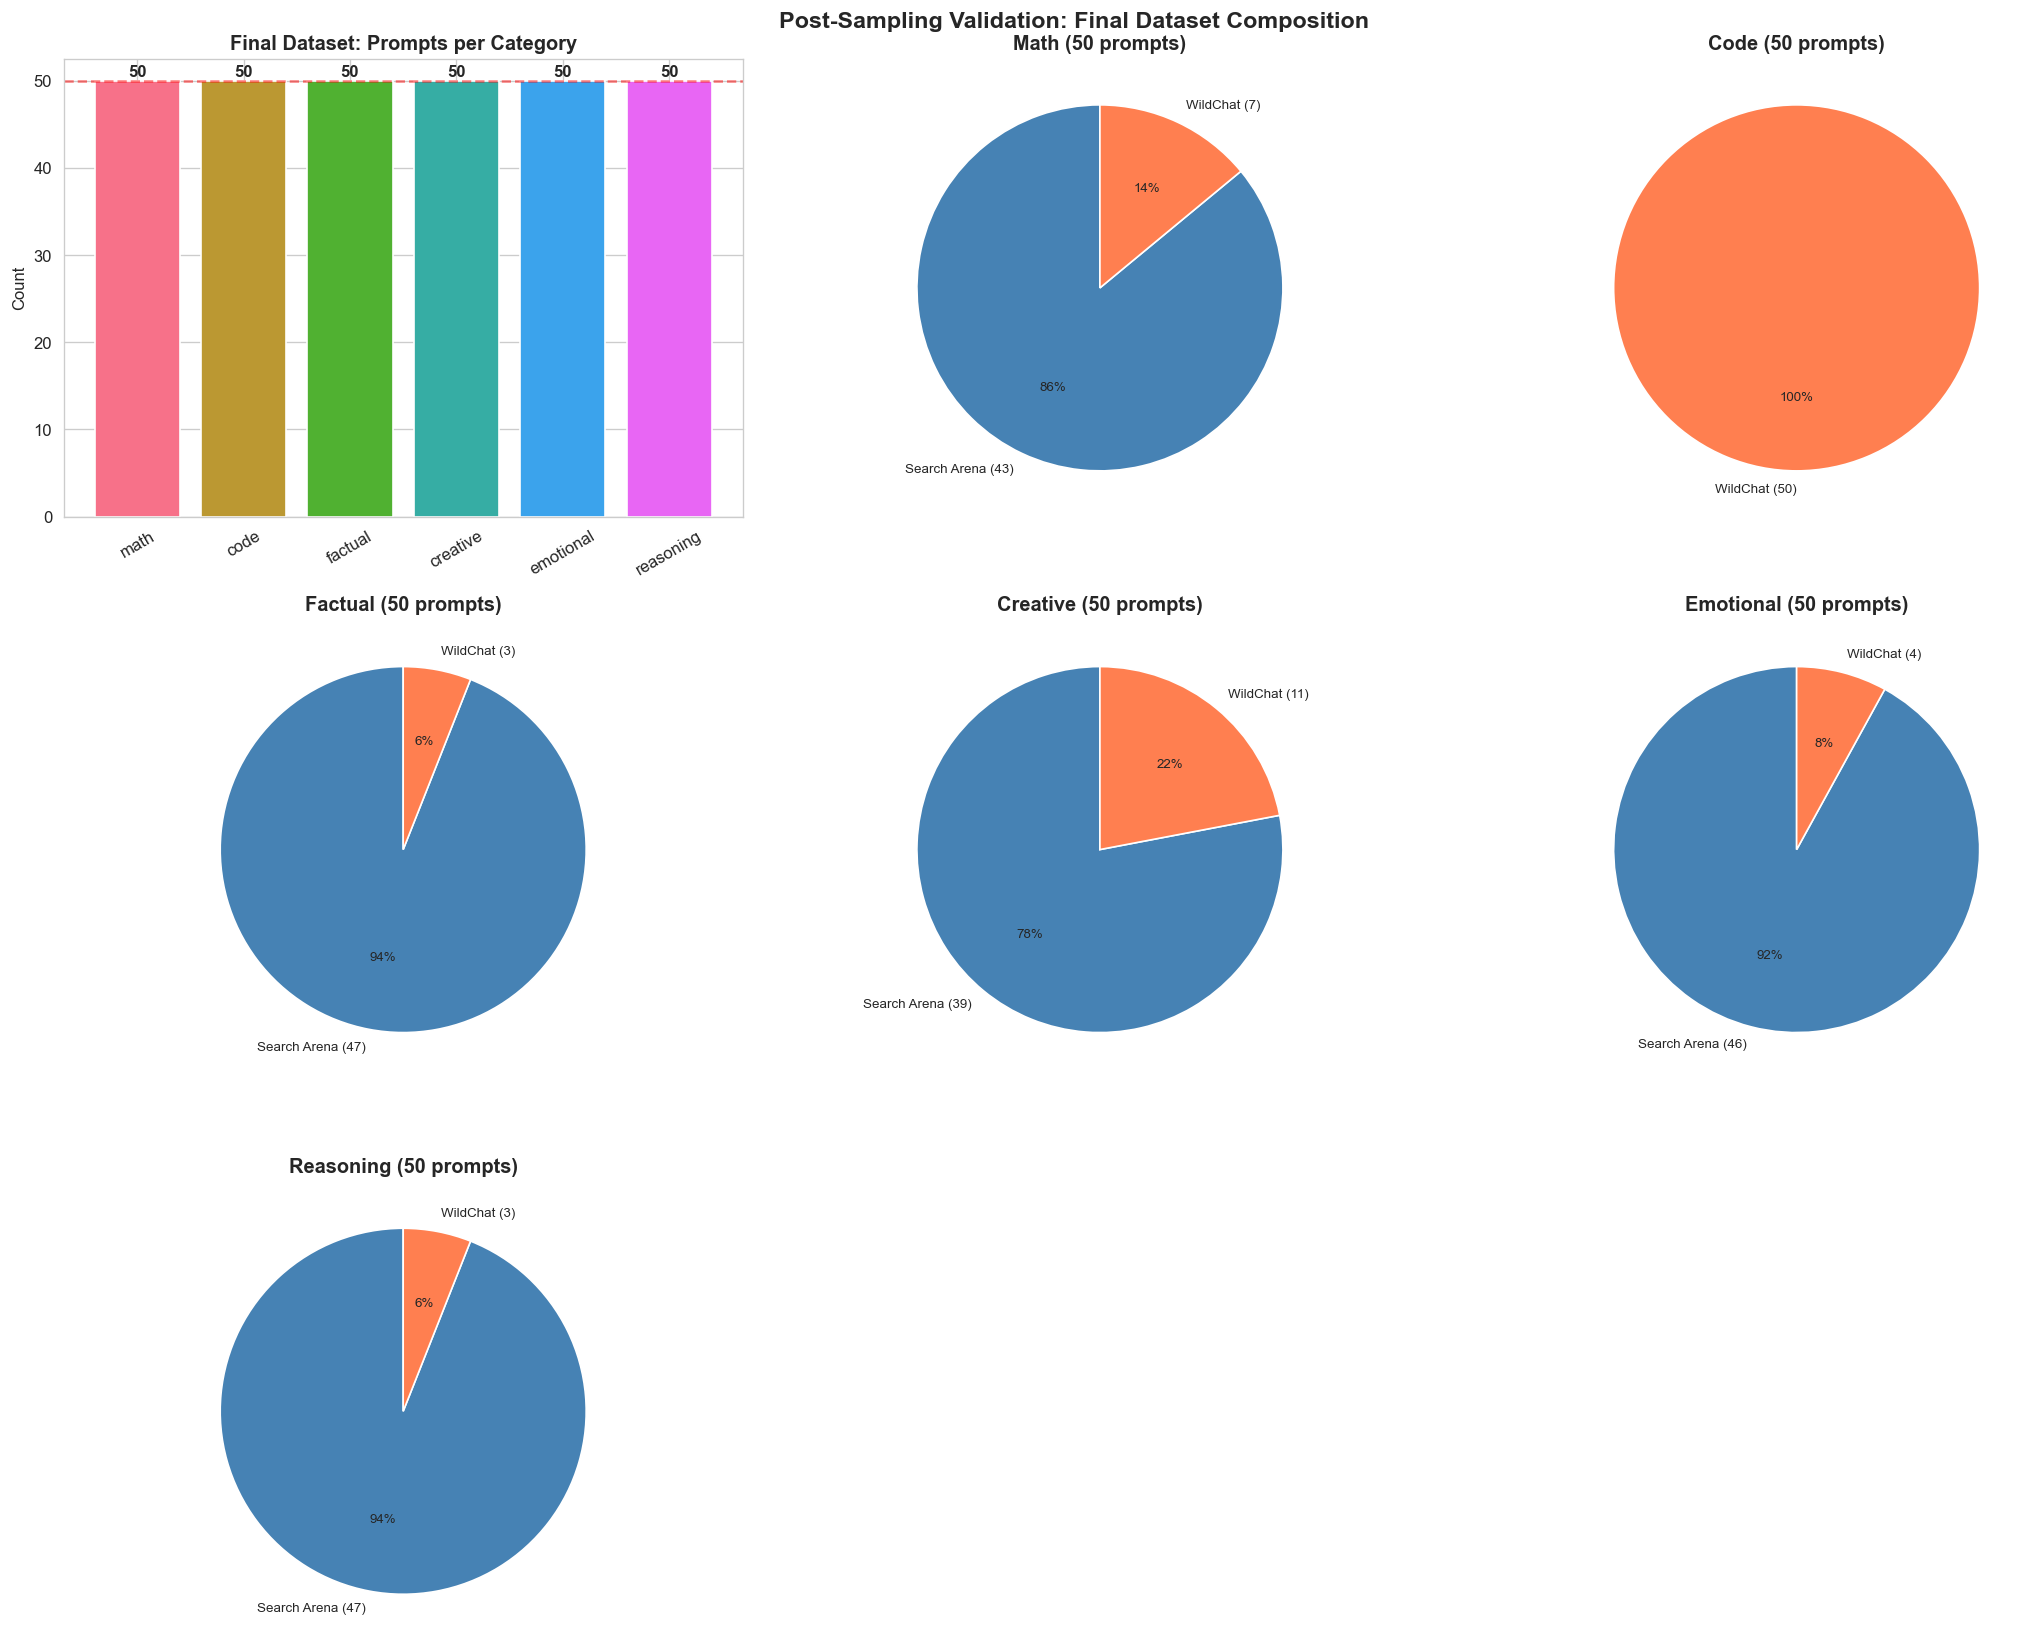

--- Sample Prompts from Final Dataset ---
[MATH]
  1. (search_arena) Analyze this guide: https://attachments.f95zone.to/2020/11/917091_Maid_Mansion_Official_Walkthrough.txt. Then, write a walkthrough that allows the pla...
  2. (wildchat) A segment of current‐carrying wire passes through a uniform magnetic field of 100T at an angle
of θ = 30° and the current is 0.32 A.  
A. What is the ...
  3. (search_arena) busca en las paginas de motorola, samsung y xiaomi, asi como en sitios especializados en analisis de telefonos moviles.
de cuantos años sera el soport...
[CODE]
  1. (wildchat) Create a script for predicting oil price for yhenext nine months using blstm on historicaldata.   The script is in R notebook for Google colab
  2. (wildchat) Which services describes AWS CloudFormation templates?
  3. (wildchat) my string output of an python function is this:
b'Playing\n'

i only want the word that is in between the b' and \n'
[FACTUAL]
  1. (search_arena) найди 10 новостей про связь РФ на

In [18]:
# ─── Cell 13: EDA — Post-Sampling Validation ─────────────────────────────────

# Use a 3x3 grid: first cell = bar chart, remaining 6 = pie charts per category
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes_flat = axes.flatten()

# 13a. Final category balance
final_sizes = [len(final_prompts[c]) for c in CATEGORIES]
axes_flat[0].bar(CATEGORIES, final_sizes, color=sns.color_palette('husl', 6))
axes_flat[0].set_title('Final Dataset: Prompts per Category', fontweight='bold')
axes_flat[0].set_ylabel('Count')
axes_flat[0].axhline(TARGET_PER_CATEGORY, color='red', linestyle='--', alpha=0.5)
for i, v in enumerate(final_sizes):
    axes_flat[0].text(i, v + 0.5, str(v), ha='center', fontweight='bold')
axes_flat[0].tick_params(axis='x', rotation=30)

# 13b-g. Source provenance pie charts per category (slots 1-6)
for i, cat in enumerate(CATEGORIES):
    ax = axes_flat[i + 1]
    sa_n = sum(1 for m in final_metadata[cat] if m['source'] == 'search_arena')
    wc_n = sum(1 for m in final_metadata[cat] if m['source'] == 'wildchat')
    sizes = [sa_n, wc_n]
    labels = [f'Search Arena ({sa_n})', f'WildChat ({wc_n})']
    colors_pie = ['steelblue', 'coral']
    # Only include non-zero slices
    nonzero = [(s, l, c) for s, l, c in zip(sizes, labels, colors_pie) if s > 0]
    if nonzero:
        ax.pie([s for s, l, c in nonzero],
               labels=[l for s, l, c in nonzero],
               colors=[c for s, l, c in nonzero],
               autopct='%1.0f%%', startangle=90, textprops={'fontsize': 8})
    ax.set_title(f'{cat.capitalize()} ({sa_n + wc_n} prompts)', fontweight='bold')

# Hide unused subplots (slots 7-8)
for j in range(len(CATEGORIES) + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle('Post-Sampling Validation: Final Dataset Composition', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda_post_sampling.png', dpi=150, bbox_inches='tight')
plt.show()

# Show 3 sample prompts per category
print('--- Sample Prompts from Final Dataset ---')
for cat in CATEGORIES:
    print(f'[{cat.upper()}]')
    for i, p in enumerate(final_prompts[cat][:3]):
        display_p = p[:150] + '...' if len(p) > 150 else p
        src = final_metadata[cat][i]['source']
        print(f'  {i+1}. ({src}) {display_p}')

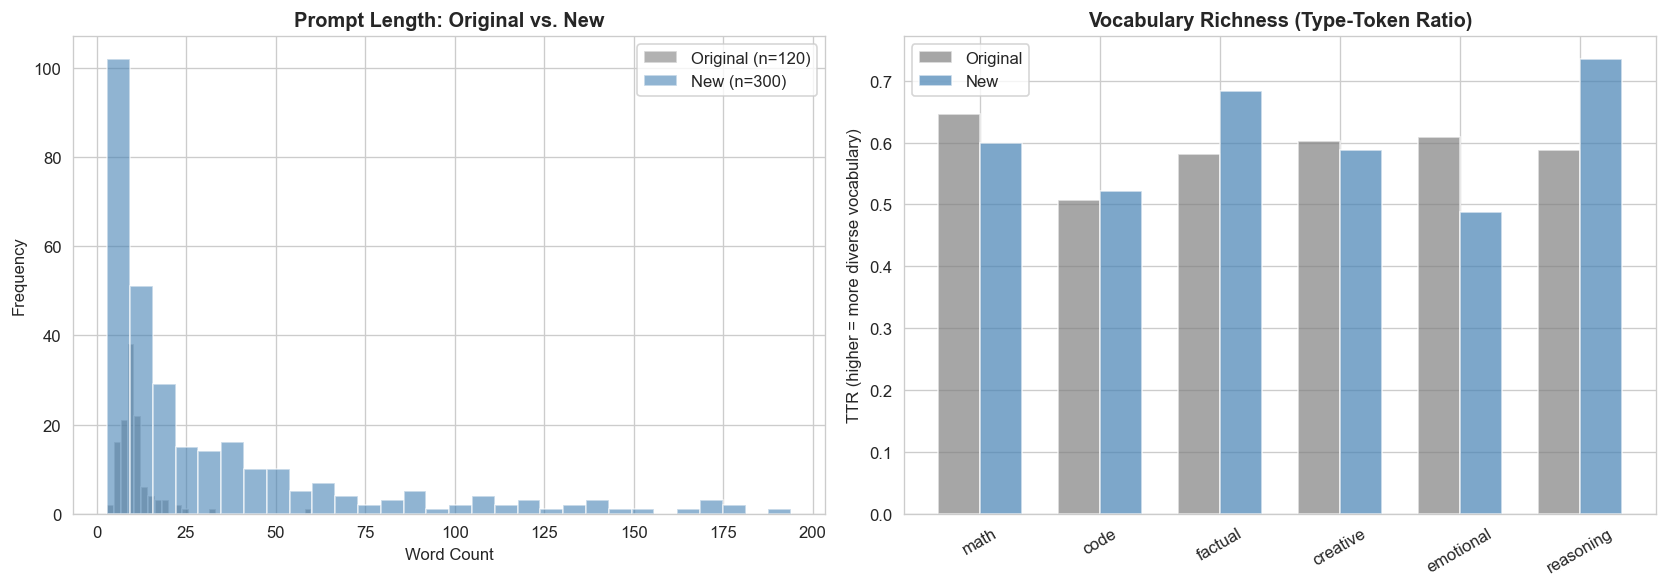


--- Side-by-Side Comparison: Original vs. New ---

[MATH]
  Original: What is 15 plus 27?
  New:      Analyze this guide: https://attachments.f95zone.to/2020/11/917091_Maid_Mansion_Official_Walkthrough.txt. Then, write a w

[CODE]
  Original: Write a Python function to check if a string is a palindrome.
  New:      Create a script for predicting oil price for yhenext nine months using blstm on historicaldata.   The script is in R not

[FACTUAL]
  Original: What is the capital of France?
  New:      найди 10 новостей про связь РФ на СВО и связистов РФ на СВО за первый квартал 2025 года с предоставлением ссылок

[CREATIVE]
  Original: Write a short poem about a rainy afternoon.
  New:      Написать диплома на тему "Оборудование участка жд устройствами КТСМ-03"

[EMOTIONAL]
  Original: I just lost my job and I feel hopeless. What should I do?
  New:      Write a quick text to Mary, how her Division (Business Engagement Services) might be interested in Harvard Kennedy Schoo

[REASONING]
 

In [21]:
# â”€â”€â”€ Cell 14: Comparison â€” Old (Hand-Curated) vs New (Real) Prompts â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# Load the original dataset for comparison
with open(DATA_DIR / 'prompts_original.json', encoding='utf-8') as f:
    original = json.load(f)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 14a. Length distribution comparison
orig_lengths = [len(p.split()) for cat in original for p in original[cat]]
new_lengths = [len(p.split()) for cat in final_prompts for p in final_prompts[cat]]

axes[0].hist(orig_lengths, bins=30, alpha=0.6, label=f'Original (n={len(orig_lengths)})',
             color='gray', edgecolor='white')
axes[0].hist(new_lengths, bins=30, alpha=0.6, label=f'New (n={len(new_lengths)})',
             color='steelblue', edgecolor='white')
axes[0].set_title('Prompt Length: Original vs. New', fontweight='bold')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# 14b. Type-token ratio (vocabulary richness) per category
orig_ttr = {}
new_ttr = {}
for cat in CATEGORIES:
    # Original
    words = [w.lower() for p in original.get(cat, []) for w in p.split()]
    orig_ttr[cat] = len(set(words)) / len(words) if words else 0
    # New
    words = [w.lower() for p in final_prompts[cat] for w in p.split()]
    new_ttr[cat] = len(set(words)) / len(words) if words else 0

x = np.arange(len(CATEGORIES))
w = 0.35
axes[1].bar(x - w/2, [orig_ttr[c] for c in CATEGORIES], w, label='Original', color='gray', alpha=0.7)
axes[1].bar(x + w/2, [new_ttr[c] for c in CATEGORIES], w, label='New', color='steelblue', alpha=0.7)
axes[1].set_xticks(x)
axes[1].set_xticklabels(CATEGORIES, rotation=30)
axes[1].set_title('Vocabulary Richness (Type-Token Ratio)', fontweight='bold')
axes[1].set_ylabel('TTR (higher = more diverse vocabulary)')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda_old_vs_new.png', dpi=150, bbox_inches='tight')
plt.show()

# Side-by-side examples
print('\n--- Side-by-Side Comparison: Original vs. New ---')
for cat in CATEGORIES:
    print(f'\n[{cat.upper()}]')
    orig_ex = original.get(cat, ['(none)'])[0]
    new_ex = final_prompts[cat][0] if final_prompts[cat] else '(none)'
    print(f'  Original: {orig_ex[:120]}')
    print(f'  New:      {new_ex[:120]}')

In [23]:
# ─── Cell 15: Save Final Dataset ─────────────────────────────────────────────

# Save in pipeline-compatible format: {category: [list of strings]}
with open(DATA_DIR / 'prompts.json', 'w', encoding='utf-8') as f:
    json.dump(final_prompts, f, indent=2, ensure_ascii=False)
print(f'Saved data/prompts.json ({sum(len(v) for v in final_prompts.values())} prompts)')

# Save metadata for provenance tracking
with open(DATA_DIR / 'prompts_metadata.json', 'w', encoding='utf-8') as f:
    json.dump(final_metadata, f, indent=2, ensure_ascii=False)
print(f'Saved data/prompts_metadata.json')

# Save full pool for reproducibility
with open(DATA_DIR / 'prompt_pool.json', 'w', encoding='utf-8') as f:
    json.dump({cat: pool[cat] for cat in CATEGORIES}, f, indent=2, ensure_ascii=False)
print(f'Saved data/prompt_pool.json ({sum(len(v) for v in pool.values())} total candidates)')

# Verify the saved file loads correctly
with open(DATA_DIR / 'prompts.json', encoding='utf-8') as f:
    verify = json.load(f)
print(f'Verification - loaded {sum(len(v) for v in verify.values())} prompts:')
for cat in CATEGORIES:
    print(f'  {cat}: {len(verify[cat])}')

Saved data/prompts.json (300 prompts)
Saved data/prompts_metadata.json
Saved data/prompt_pool.json (13851 total candidates)
Verification - loaded 300 prompts:
  math: 50
  code: 50
  factual: 50
  creative: 50
  emotional: 50
  reasoning: 50


In [24]:
# â”€â”€â”€ Cell 16: Summary Statistics Table â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€

summary_rows = []
for cat in CATEGORIES:
    prompts = final_prompts[cat]
    word_lens = [len(p.split()) for p in prompts]
    tok_lens = [len(tokenizer.encode(p)) for p in prompts]
    sa_n = sum(1 for m in final_metadata[cat] if m['source'] == 'search_arena')
    wc_n = sum(1 for m in final_metadata[cat] if m['source'] == 'wildchat')
    words_all = [w.lower() for p in prompts for w in p.split()]
    ttr = len(set(words_all)) / len(words_all) if words_all else 0

    summary_rows.append({
        'Category': cat.capitalize(),
        'N': len(prompts),
        'Avg Words': f'{np.mean(word_lens):.1f}',
        'Med Words': f'{np.median(word_lens):.0f}',
        'Avg Tokens': f'{np.mean(tok_lens):.1f}',
        'Max Tokens': max(tok_lens),
        'SA Count': sa_n,
        'WC Count': wc_n,
        'TTR': f'{ttr:.3f}',
    })

summary_df = pd.DataFrame(summary_rows)
print('\n' + '=' * 90)
print('FINAL DATASET SUMMARY')
print('=' * 90)
print(summary_df.to_string(index=False))
print('=' * 90)
print(f'\nTotal: {sum(len(v) for v in final_prompts.values())} prompts')
print(f'Sources: Search Arena 24k (lmarena-ai) + WildChat 4.8M (how2everything)')
print(f'Quality filters: length (3-200 words), alpha ratio (>0.5), token limit ({MAX_TOKENS}), dedup')
print(f'Math/Emotional: keyword-based sub-classification from parent topics')
print(f'\nDataset saved to: data/prompts.json')
print('Ready for feature extraction in Notebook 02!')


FINAL DATASET SUMMARY
 Category  N Avg Words Med Words Avg Tokens  Max Tokens  SA Count  WC Count   TTR
     Math 50      35.6        20       75.9         271        43         7 0.599
     Code 50      34.7        21       85.5         508         0        50 0.522
  Factual 50      13.5         8       25.1         117        47         3 0.684
 Creative 50      30.7        12       60.9         274        39        11 0.587
Emotional 50      60.6        40       90.2         318        46         4 0.487
Reasoning 50      18.5        13       47.6         366        47         3 0.735

Total: 300 prompts
Sources: Search Arena 24k (lmarena-ai) + WildChat 4.8M (how2everything)
Quality filters: length (3-200 words), alpha ratio (>0.5), token limit (512), dedup
Math/Emotional: keyword-based sub-classification from parent topics

Dataset saved to: data/prompts.json
Ready for feature extraction in Notebook 02!
